## 야후 파이넨스 (yfinance)

-  는 저 세계 주식 , ETF, 암호화폐의 실시간 및 과거 데이터를 코드 한 줄로 내 파이썬 노트북에 가뎌와 주는 "무료 금융 데이터 치트키"라이브 러리입니다
-  기존에 사이트에서 CSV파일을 다운로드 할 수 있지만, 종목이 많아지면 관리하기 어렵기 떄문에 라이브러리 사용을 권장합니다

[야후 파이넨스 공식 링크](https://finance.yahoo.com/)

In [14]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
from curl_cffi import requests as cffi_requests

warnings.filterwarnings('ignore')

# 윈도우 맑은 고딕 설정
# plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 맥 애플고딕 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [15]:
session = cffi_requests.Session(impersonate="chrome")

tickers = ["JEPQ", "JEPI", "NVDA", "MSFT"]
all_data = {}

for t in tickers:
    df = yf.download(t, start="2024-01-01", end="2026-09-01", session=session, threads=False)
    all_data[t] = df
    time.sleep(5)

all_data

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


{'JEPQ': Price           Close       High        Low       Open   Volume
 Ticker           JEPQ       JEPQ       JEPQ       JEPQ     JEPQ
 Date                                                           
 2024-01-02  37.038418  37.195328  36.920360  37.195328  3137400
 2024-01-03  36.776897  36.920357  36.732065  36.881504  2316600
 2024-01-04  36.627464  36.874037  36.612520  36.664823  2790100
 2024-01-05  36.724594  36.896448  36.612514  36.642402  2798000
 2024-01-08  37.284988  37.292459  36.806782  36.814255  2124500
 ...               ...        ...        ...        ...      ...
 2026-08-25  59.072330  59.220631  58.849884  59.092104  4602500
 2026-08-26  59.111877  59.210742  58.924030  58.943804  4441800
 2026-08-27  59.625980  59.643774  59.279948  59.448022  4667600
 2026-08-28  59.467796  59.823710  59.388702  59.586434  6185300
 2026-08-31  59.537003  59.566661  59.319497  59.467797  8095700
 
 [668 rows x 5 columns],
 'JEPI': Price           Close       High        Low   

In [16]:
all_data["NVDA"].head()

Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2024-01-02,48.028793,49.152535,47.457451,49.101684,411254000
2024-01-03,47.431526,48.044747,47.183245,47.347769,320896000
2024-01-04,47.859291,48.359839,47.370705,47.628956,306535000
2024-01-05,48.955101,49.403801,48.166387,48.321938,415039000
2024-01-08,52.101986,52.123926,49.336005,49.368910,642510000


In [17]:
all_data["NVDA"].columns

MultiIndex([( 'Close', 'NVDA'),
            (  'High', 'NVDA'),
            (   'Low', 'NVDA'),
            (  'Open', 'NVDA'),
            ('Volume', 'NVDA')],
           names=['Price', 'Ticker'])

## 데이터 준비


In [18]:
close_df = pd.DataFrame()

# all_data -> tickers -> Close 데이터만 가져오겠다는 의미

for t in tickers:
    close_df[t] = all_data[t]["Close"]

print(close_df)

                 JEPQ       JEPI        NVDA        MSFT
Date                                                    
2024-01-02  37.038418  44.692711   48.028793  363.117889
2024-01-03  36.776897  44.441338   47.431526  362.853577
2024-01-04  36.627464  44.425129   47.859291  360.249146
2024-01-05  36.724594  44.392700   48.955101  360.063202
2024-01-08  37.284988  44.692711   52.101986  366.858093
...               ...        ...         ...         ...
2026-08-25  59.072330  57.764870  212.811874  491.709991
2026-08-26  59.111877  57.784740  209.425659  496.369995
2026-08-27  59.625980  57.476738  227.725174  505.059998
2026-08-28  59.467796  57.417130  217.306839  513.530029
2026-08-31  59.537003  57.128998  220.533234  507.290009

[668 rows x 4 columns]


## 데이터 전처리 

In [19]:
close_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 668 entries, 2024-01-02 to 2026-08-31
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   JEPQ    668 non-null    float64
 1   JEPI    668 non-null    float64
 2   NVDA    668 non-null    float64
 3   MSFT    668 non-null    float64
dtypes: float64(4)
memory usage: 26.1 KB


In [20]:
close_df.describe()

,JEPQ,JEPI,NVDA,MSFT
count,668.000000,668.000000,668.000000,668.000000
mean,47.879984,51.286076,147.299539,431.921963
std,6.121773,3.362889,43.831636,44.189092
min,36.627464,44.392700,47.431526,350.446106
25%,42.768599,48.528729,115.916479,400.007019
50%,47.085588,51.441778,141.016609,417.746307
75%,53.268996,54.248923,183.702614,470.046600
max,59.873146,57.784740,235.202393,537.646423


In [21]:
close_df.describe()

,JEPQ,JEPI,NVDA,MSFT
count,668.000000,668.000000,668.000000,668.000000
mean,47.879984,51.286076,147.299539,431.921963
std,6.121773,3.362889,43.831636,44.189092
min,36.627464,44.392700,47.431526,350.446106
25%,42.768599,48.528729,115.916479,400.007019
50%,47.085588,51.441778,141.016609,417.746307
75%,53.268996,54.248923,183.702614,470.046600
max,59.873146,57.784740,235.202393,537.646423


## 초기 가설 
- NVDA, MSFT 갭별 성장주 이기 때문에 단기 변동성이 크더라도 복리효과가 누적되면서 장기적인 우상향을 보여줄  것이다
- JEPQ, JEPI 배당 성장현 ETF이기때문에 수익룰이 낮고 , 상승기가 낮더라도 시장의 조정기 마다 고점 대비 자산이 깎이는 낙폭으이 낮았을 것이다
- 2024년도 조정기에 ETF 중 표준편차가 낮은 JPI가 방어력아 가장 좋았을 것이다 

In [22]:
# .pct_change(): 변화율을 구해주는 함수
# ex) (오늘 종가 - 어제 종가) / 어제 종가
returns_df = close_df.pct_change().dropna()
returns_df

,JEPQ,JEPI,NVDA,MSFT
Date,,,,
2024-01-03,-0.007061,-0.005624,-0.012436,-0.000728
2024-01-04,-0.004063,-0.000365,0.009019,-0.007178
2024-01-05,0.002652,-0.000730,0.022896,-0.000516
2024-01-08,0.015259,0.006758,0.064281,0.018871
2024-01-09,0.002204,-0.000726,0.016975,0.002936
...,...,...,...,...
2026-08-25,0.005554,0.000861,0.021921,0.009029
2026-08-26,0.000669,0.000344,-0.015912,0.009477
2026-08-27,0.008697,-0.005330,0.087380,0.017507


In [23]:
# cumprod: 누적율 구하는 메서드 
cum_returns_df = (1 + returns_df).cumprod() - 1
cum_returns_df

,JEPQ,JEPI,NVDA,MSFT
Date,,,,
2024-01-03,-0.007061,-0.005624,-0.012436,-0.000728
2024-01-04,-0.011095,-0.005987,-0.003529,-0.007900
2024-01-05,-0.008473,-0.006713,0.019287,-0.008412
2024-01-08,0.006657,0.000000,0.084807,0.010300
2024-01-09,0.008876,-0.000726,0.103222,0.013266
...,...,...,...,...
2026-08-25,0.594893,0.292490,3.430923,0.354133
2026-08-26,0.595961,0.292934,3.360419,0.366967
2026-08-27,0.609841,0.286043,3.741430,0.390898


In [24]:
# cummax: 이전 값과 비효하여 최고 값으로 대체
peak_df = close_df.cummax()
peak_df

,JEPQ,JEPI,NVDA,MSFT
Date,,,,
2024-01-02,37.038418,44.692711,48.028793,363.117889
2024-01-03,37.038418,44.692711,48.028793,363.117889
2024-01-04,37.038418,44.692711,48.028793,363.117889
2024-01-05,37.038418,44.692711,48.955101,363.117889
2024-01-08,37.284988,44.692711,52.101986,366.858093
...,...,...,...,...
2026-08-25,59.873146,57.764870,235.202393,537.646423
2026-08-26,59.873146,57.784740,235.202393,537.646423
2026-08-27,59.873146,57.784740,235.202393,537.646423


In [25]:
# 고점대비 낙폭 
                # 종가   -  최고값
drawdown_df = (close_df - peak_df) / peak_df
drawdown_df

,JEPQ,JEPI,NVDA,MSFT
Date,,,,
2024-01-02,0.000000,0.000000,0.000000,0.000000
2024-01-03,-0.007061,-0.005624,-0.012436,-0.000728
2024-01-04,-0.011095,-0.005987,-0.003529,-0.007900
2024-01-05,-0.008473,-0.006713,0.000000,-0.008412
2024-01-08,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...
2026-08-25,-0.013375,0.000000,-0.095197,-0.085440
2026-08-26,-0.012715,0.000000,-0.109594,-0.076772
2026-08-27,-0.004128,-0.005330,-0.031791,-0.060609


In [26]:
# 수익의 변동성(표준편차) * 미국 주식(252) - 휴장일을 제외한 미국의 주식 일수
# 연율화(미국 주식의 "년"단위 변동성)
annual_vol = returns_df.std() * np.sqrt(252)
annual_vol

mdd = drawdown_df.min()
mdd

v1_proof = pd.DataFrame({
    "최종 누적 수익률(%)": cum_returns_df.iloc[-1] * 100,
    "연율화 변동성(%)": annual_vol * 100,
    "최대 낙폭 MDD(%)": mdd * 100
})

v1_proof

,최종 누적 수익률(%),연율화 변동성(%),최대 낙폭 MDD(%)
JEPQ,60.743914,16.137027,-20.069901
JEPI,27.826209,10.279541,-13.257840
NVDA,359.168799,48.437015,-36.881027
MSFT,39.703943,26.850657,-34.498398


In [27]:
cum_returns_df.index


DatetimeIndex(['2024-01-03', '2024-01-04', '2024-01-05', '2024-01-08',
               '2024-01-09', '2024-01-10', '2024-01-11', '2024-01-12',
               '2024-01-16', '2024-01-17',
               ...
               '2026-08-18', '2026-08-19', '2026-08-20', '2026-08-21',
               '2026-08-24', '2026-08-25', '2026-08-26', '2026-08-27',
               '2026-08-28', '2026-08-31'],
              dtype='datetime64[s]', name='Date', length=667, freq=None)

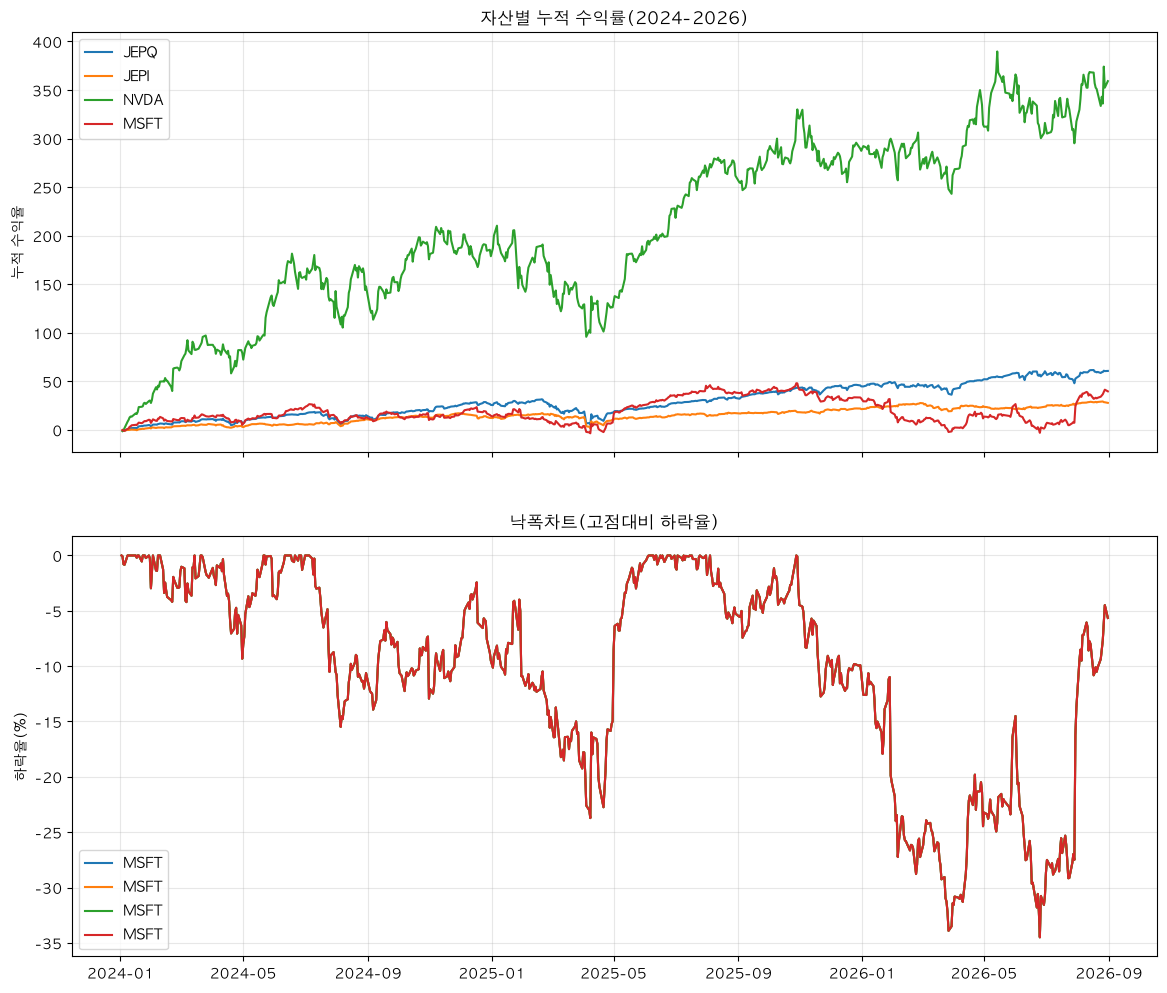

In [28]:
fig, axes = plt.subplots(2, 1, figsize= (14, 12), sharex=True)

for t in tickers: 
    
    # ㅌ측 : cum_return_df.index(일자): 누적값의 인덱스
    # y축 : cum_return_df[t] * 100 : 누적값의 값
    axes[0].plot(cum_returns_df.index, cum_returns_df[t] * 100, label=t)
    axes[0].set_title("자산별 누적 수익률(2024-2026)")

    axes[0].set_ylabel("누적 수익율")
    # legend() : 범례도 
    axes[0].legend()
    # alpha=0.3: 투명도  30%
    axes[0].grid(True, alpha=0.3)

for i in tickers:
    axes[1].plot(drawdown_df.index, drawdown_df[t] * 100, label=t)
    axes[1].set_title("낙폭차트(고점대비 하락율)")
    axes[1].set_ylabel("하락율(%)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.show()

## 가설 2
- 배당형 ETP
- JEPQ는 나스갇 100 기반으로 상장된 ETF이므로, NVDA , MSFT와 높은 상관간개를 를 가질 것이다
- JEPI는 S&P 500 기반으로 산자ㅇ도ㅟㄴ EfF이므로,  NVDA , MSFT낮은 상관관계를 가질 것이다 

In [29]:
# .rolling(): 20일 설정 
# .corr)_: 최근 20일 간의 상관관계를 매일 계산해서 반환
returns_df = close_df.pct_change().dropna()
returns_df

rolling_jepi = returns_df["NVDA"].rolling(window=20).corr(returns_df["JEPI"])
rolling_jepq = returns_df["NVDA"].rolling(window=20).corr(returns_df["JEPQ"])

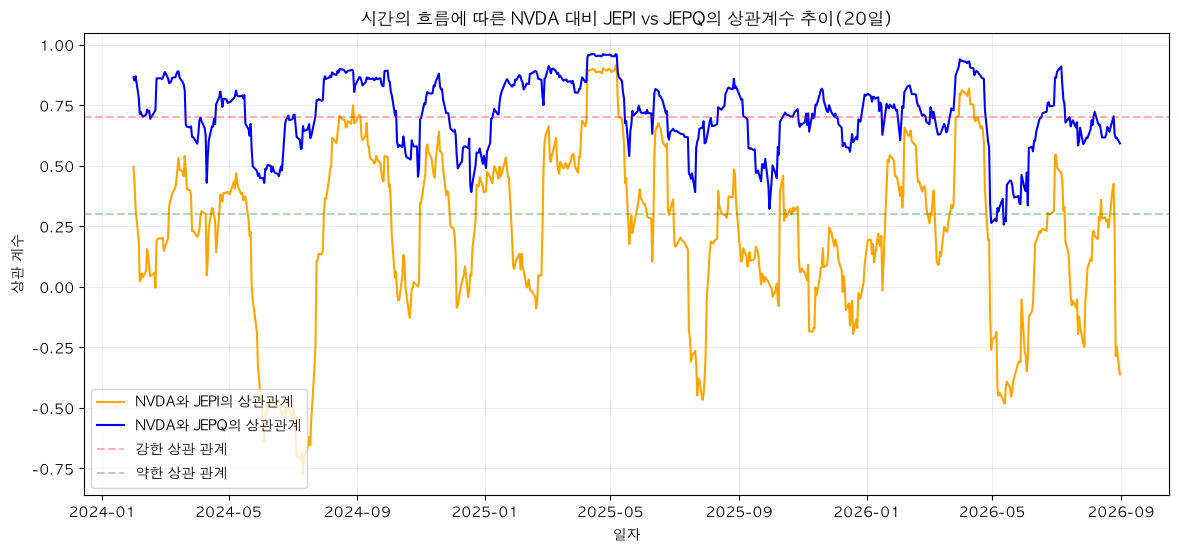

In [35]:
plt.figure(figsize=(14, 6)) 
plt.plot(rolling_jepi.index, rolling_jepi, label="NVDA와 JEPI의 상관관계", color="orange")
plt.plot(rolling_jepq.index, rolling_jepq, label="NVDA와 JEPQ의 상관관계", color="blue")

plt.axhline(0.7, color="red", linestyle="--", alpha=0.3, label="강한 상관 관계")
plt.axhline(0.3, color="green", linestyle="--", alpha=0.3, label="약한 상관 관계")

plt.title("시간의 흐름에 따른 NVDA 대비 JEPI vs JEPQ의 상관계수 추이(20일)")
plt.ylabel("상관 계수")
plt.xlabel("일자")
plt.legend(loc="lower left")
plt.grid(True, alpha=0.2)

plt.show()

## 가설 검증 결과 
- JEPQ와 NVDA는 지속적 0.7이상의 높은 상관관계를 유지하며 동조화가 잘 되고 있다
- 반대로 는  와의 상관관계가 0.4 의 낮은 상관관계를 유지하며 동조화가 잘 되고 있다
- 성장두 리스크를 부나산하고 싶을 때는 JEPI를 추천해서 자산을 배분해야한다
- 가설은 찬, 가설 채택

## EDA 시각화 
역사적 고점 대비 대략 20%가 떨어질 때 사면, 이후 한 달 뒤에 얼마정도릐 수익을 볼 확률, 평균 수익룰은 어떻게될까?

In [31]:
forward_days = 20
result = []

for t in tickers:
    # 20일 뒤 주가 / 현재 주가  -1 (20일 종안의 수익율)
                # .shift() : 배열에 오는거 슬라이싱함  \ -forward_days     
    rwd_return_df = (close_df[t].shift(-forward_days) / close_df[t])-1

    drawdown = drawdown_df_df[t]  # 낙폭율 / 수익율 
    df_temp = pd.DataFrame({"Drawdown": drawdown, "FwdReturn": fwd_return_df}).dropna()

    # 구간
    bins = [-1.0, -0.2, -0.1, -0.05, 0.001]
    labels = ["-20%이하(대폭락)", "-10% ~ -20%", "-5% ~ -10%", "0% ~ -5%"]

    df_temp["구간"] = pd.cut(df_temp["Drawdown"], bins=bins, labels= labels

print(df_temp)

SyntaxError: '(' was never closed (1970674259.py, line 15)